In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import InceptionV3

In [ ]:
# Load pre-trained InceptionV3 model without the top layer
inception_base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(*IMAGE_SIZE, 3))

# Add custom layers on top of the base model
x_inception = inception_base_model.output
x_inception = GlobalAveragePooling2D()(x_inception)
x_inception = Dense(1024, activation='relu')(x_inception)
x_inception = Dense(512, activation='relu')(x_inception)
inception_predictions = Dense(len(class_names), activation='softmax')(x_inception)

# Define InceptionV3 model
inception_model = Model(inputs=inception_base_model.input, outputs=inception_predictions)

# Freeze the base model layers
for layer in inception_base_model.layers:
    layer.trainable = False

# Compile InceptionV3 model
inception_model.compile(optimizer=Adam(learning_rate=0.000001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

# Train InceptionV3
history_inception = inception_model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[csv_logger, checkpoint_cb])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2876 - loss: 12.1711
Epoch 1: val_accuracy did not improve from 0.84965
240/240 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.2879 - loss: 12.1323 - val_accuracy: 0.4000 - val_loss: 3.8938
Epoch 2/50
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4018 - loss: 3.5405
Epoch 2: val_accuracy did not improve from 0.84965
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.4019 - loss: 3.5384 - val_accuracy: 0.4333 - val_loss: 2.7345
Epoch 3/50
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4400 - loss: 2.6231
Epoch 3: val_accuracy did not improve from 0.84965
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.4400 - loss: 2.6221 - val_accuracy: 0.4559 - val_loss: 2.2559
Epoch 4/50
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4639 - loss: 2.1882
Epoch 4: val_accuracy did not improve from 0.84965
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/

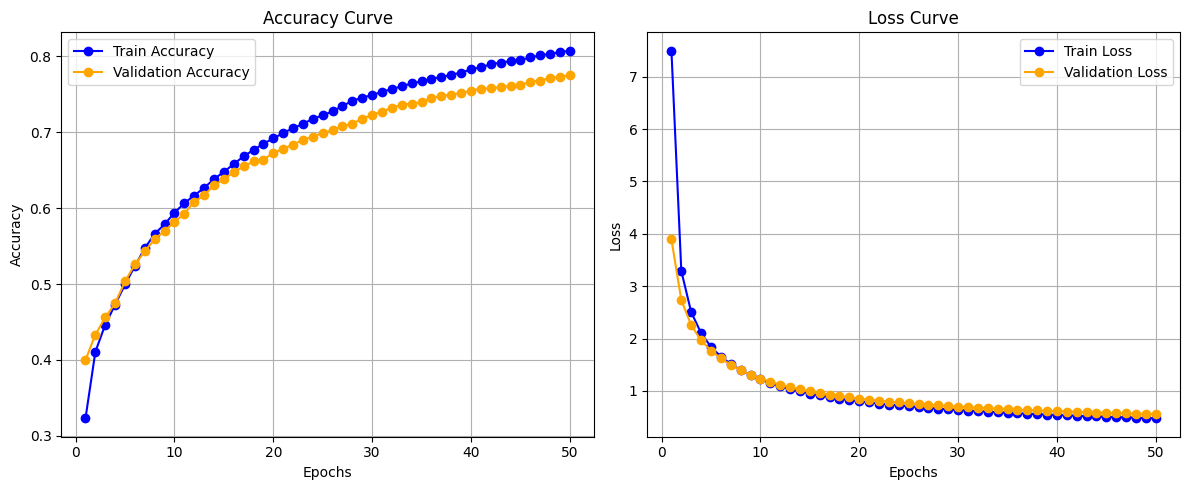

In [ ]:
# Extract accuracy and loss values from the training history
train_accuracy = history_inception.history['accuracy']
val_accuracy = history_inception.history['val_accuracy']
train_loss = history_inception.history['loss']
val_loss = history_inception.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='orange', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Adjust layout and show plots
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Evaluate InceptionV3
inception_loss, inception_accuracy = inception_model.evaluate(val_ds)
print(f"InceptionV3 Accuracy: {inception_accuracy * 100:.2f}%")

# Predict and generate confusion matrix
inception_predictions = np.argmax(inception_model.predict(val_ds), axis=1)
inception_true_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in val_ds])

# Custom function to calculate specificity for each class
def specificity_score(y_true, y_pred, class_idx):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # True Negatives (TN): Sum of all elements except the row and column of the class
    tn = np.sum(cm) - np.sum(cm[class_idx, :]) - np.sum(cm[:, class_idx]) + cm[class_idx, class_idx]
    # False Positives (FP): Sum of column for class_idx, excluding the true positive
    fp = np.sum(cm[:, class_idx]) - cm[class_idx, class_idx]
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# Classification report with specificity
print("InceptionV3 Classification Report with Specificity:")
class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
report = classification_report(inception_true_labels, inception_predictions,
                              target_names=class_names, output_dict=True)

# Calculate specificity for each class
specificities = []
for i in range(len(class_names)):
    specificity = specificity_score(inception_true_labels, inception_predictions, i)
    specificities.append(specificity)

# Print the report with specificity
for i, class_name in enumerate(class_names):
    class_report = report[class_name]
    print(f"{class_name}:")
    print(f"  Precision: {class_report['precision']:.2f}")
    print(f"  Recall: {class_report['recall']:.2f}")
    print(f"  F1-Score: {class_report['f1-score']:.2f}")
    print(f"  Specificity: {specificities[i]:.2f}")
    print(f"  Support: {class_report['support']}")

# Print overall weighted average metrics
print("\nOverall Weighted Average Metrics:")
for metric in ['precision', 'recall', 'f1-score']:
    print(f"  {metric.capitalize()}: {report['weighted avg'][metric]:.2f}")
print(f"  Support: {report['weighted avg']['support']}")

90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.7962 - loss: 0.5009
InceptionV3 Accuracy: 77.50%
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step
InceptionV3 Classification Report with Specificity:
NonDemented:
  Precision: 0.94
  Recall: 0.89
  F1-Score: 0.91
  Specificity: 0.98
  Support: 719
VeryMildDemented:
  Precision: 0.81
  Recall: 0.69
  F1-Score: 0.74
  Specificity: 0.95
  Support: 728
MildDemented:
  Precision: 0.64
  Recall: 0.77
  F1-Score: 0.70
  Specificity: 0.85
  Support: 728
ModerateDemented:
  Precision: 0.75
  Recall: 0.76
  F1-Score: 0.75
  Specificity: 0.92
  Support: 705

Overall Weighted Average Metrics:
  Precision: 0.79
  Recall: 0.78
  F1-score: 0.78
  Support: 2880


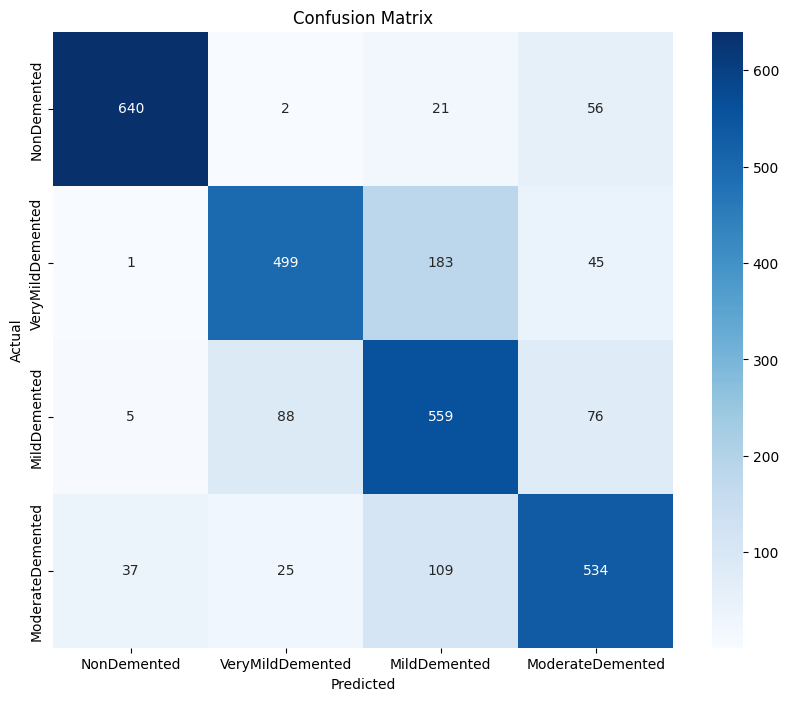

In [ ]:
# Plot confusion matrix with outer labels
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(inception_true_labels, inception_predictions),
            annot=True, cmap='Blues', fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")  # Outer label for x-axis
plt.ylabel("Actual")     # Outer label for y-axis
plt.savefig('/kaggle/working/inception_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━

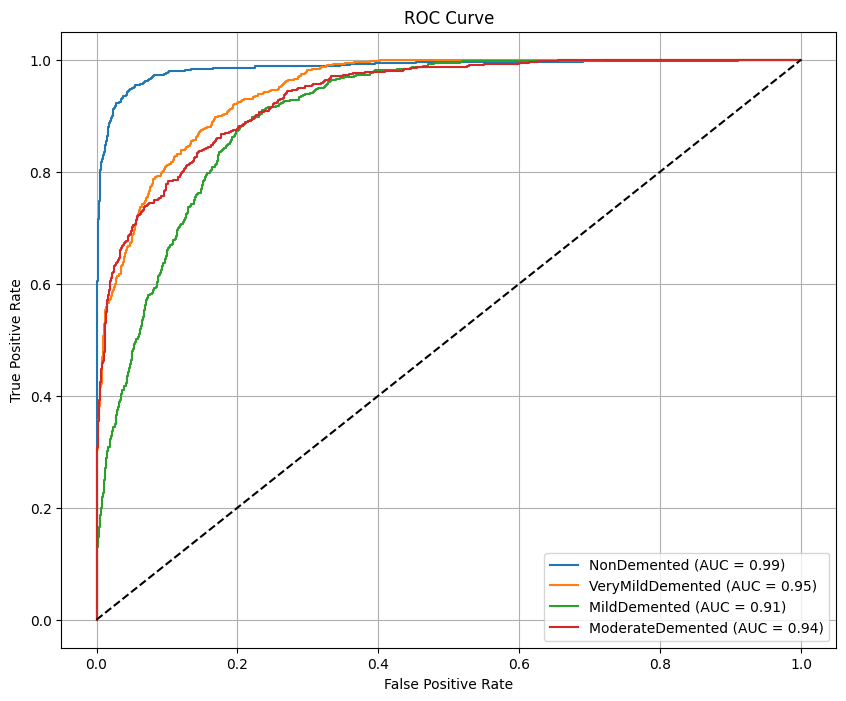

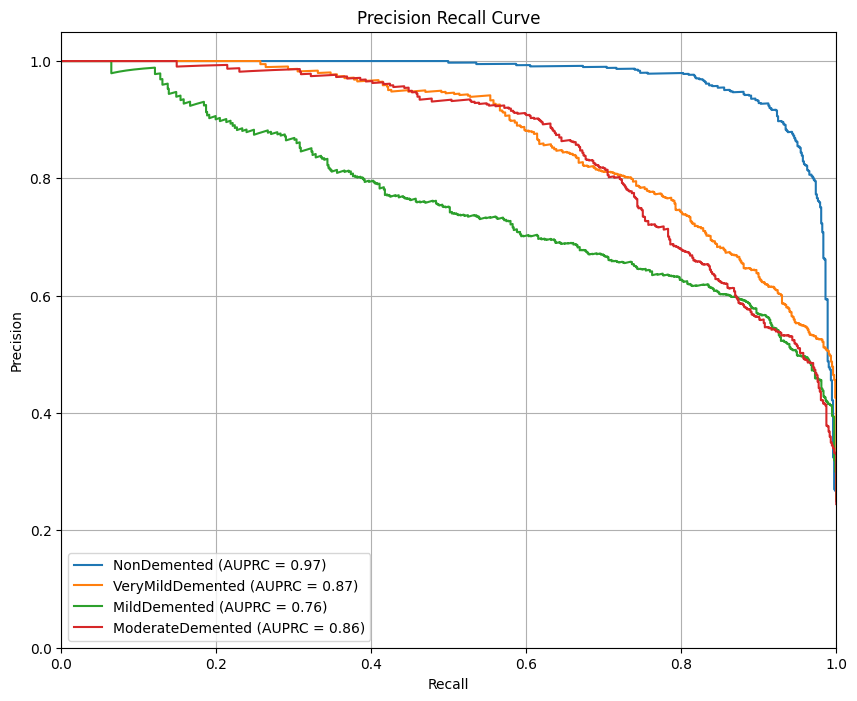

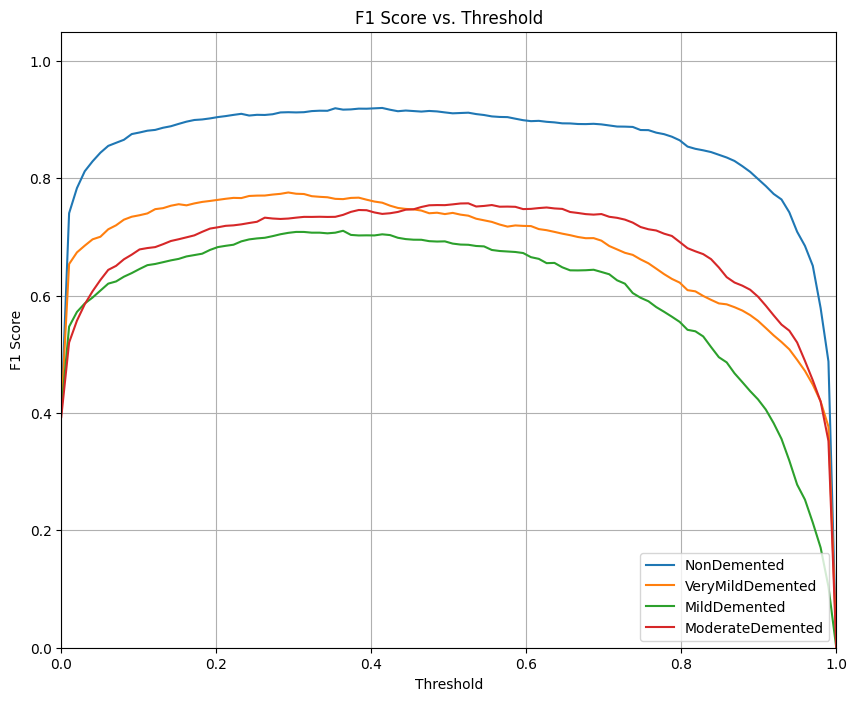

In [ ]:
# Function to plot ROC Curve
def plot_roc_curve(y_true, y_pred_prob, title, class_names):
    plt.figure(figsize=(10, 8))
    y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid()
    plt.savefig('/kaggle/working/inception_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

# Function to plot Precision-Recall Curve
def plot_precision_recall_curve(y_true, y_pred_prob, title, class_names):
    plt.figure(figsize=(10, 8))
    y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))

    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(y_true_binarized[:, i], y_pred_prob[:, i])
        auprc = auc(recall, precision)
        plt.plot(recall, precision, label=f"{class_names[i]} (AUPRC = {auprc:.2f})")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title(f'Precision Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc="lower left")
    plt.grid()
    plt.savefig('/kaggle/working/inception_precision_recall_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

# Function to plot F1 Score vs. Threshold Curve
def plot_f1_score_curve(y_true, y_pred_prob, title, class_names):
    plt.figure(figsize=(10, 8))
    y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))
    thresholds = np.linspace(0, 1, 100)

    for i in range(len(class_names)):
        f1_scores = [f1_score(y_true_binarized[:, i], (y_pred_prob[:, i] >= t).astype(int))
                     for t in thresholds]
        plt.plot(thresholds, f1_scores, label=f"{class_names[i]}")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title(f'F1 Score vs. Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.legend(loc="lower right")
    plt.grid()
    plt.savefig('/kaggle/working/inception_f1_score_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

# Assuming val_ds, inception_model, and class_names are defined
class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

# Get true labels and predicted probabilities
inception_true_labels = []
inception_pred_prob = []

for images, labels in val_ds:
    inception_true_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer labels
    inception_pred_prob.extend(inception_model.predict(images))  # Predicted probabilities

inception_true_labels = np.array(inception_true_labels)
inception_pred_prob = np.array(inception_pred_prob)

# Plot all curves
plot_roc_curve(inception_true_labels, inception_pred_prob, "InceptionV3", class_names)
plot_precision_recall_curve(inception_true_labels, inception_pred_prob, "InceptionV3", class_names)
plot_f1_score_curve(inception_true_labels, inception_pred_prob, "InceptionV3", class_names)